In [18]:
import torch
import torch.nn as nn
import numpy as np
import polars as pl
from path_config import PathConfig
import matplotlib.pyplot as plt
import copy
paths = PathConfig()

In [19]:
signal_data = pl.read_parquet(paths._processed_measured_coverage_dir / "measured_signal_coverage.parquet")
signal_data

Latitude,Longitude,30,40,59,48,68,76,3,13,23
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
41.10686,29.02151,-500.0,-76.4,-500.0,-500.0,-500.0,-500.0,-500.0,-500.0,-500.0
41.10504,29.01983,-500.0,-500.0,-500.0,-500.0,-500.0,-500.0,-500.0,-500.0,-500.0
41.10505,29.02292,-500.0,-500.0,-500.0,-500.0,-111.9,-500.0,-76.1,-500.0,-114.9
41.10805,29.02881,-500.0,-500.0,-91.4,-81.85,-500.0,-107.85,-500.0,-500.0,-500.0
41.10574,29.01534,-123.3,-500.0,-500.0,-500.0,-125.0,-123.8,-500.0,-500.0,-500.0
…,…,…,…,…,…,…,…,…,…,…
41.10553,29.02653,-500.0,-500.0,-500.0,-500.0,-73.6,-500.0,-500.0,-500.0,-500.0
41.10684,29.02639,-500.0,-500.0,-88.3,-500.0,-500.0,-96.5,-500.0,-500.0,-500.0
41.10596,29.0154,-500.0,-122.45,-500.0,-500.0,-122.0,-121.6,-500.0,-500.0,-500.0


In [20]:
calculated_coverage = pl.read_parquet(paths._processed_coverage_dir/"calculated_grid_rsrp_10m_data.parquet")
columns = ["Latitude", "Longitude", ] + [col for col in calculated_coverage.columns if "RSRP_dBm_FSPL_PCI_" in col] 
calculated_coverage = calculated_coverage[columns]
calculated_coverage

Latitude,Longitude,RSRP_dBm_FSPL_PCI_30,RSRP_dBm_FSPL_PCI_40,RSRP_dBm_FSPL_PCI_59,RSRP_dBm_FSPL_PCI_48,RSRP_dBm_FSPL_PCI_68,RSRP_dBm_FSPL_PCI_76,RSRP_dBm_FSPL_PCI_3,RSRP_dBm_FSPL_PCI_13,RSRP_dBm_FSPL_PCI_23
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
41.10609,29.014558,-98.529985,-72.496481,-88.809712,-104.287636,-80.860006,-101.949363,-74.625479,-97.960171,-95.278348
41.106181,29.014561,-98.498291,-72.486864,-89.113114,-104.269406,-81.084744,-101.954317,-74.446858,-98.010959,-95.288175
41.106271,29.014564,-98.468526,-72.4952,-89.42372,-104.251861,-81.316312,-101.960289,-74.289338,-98.06394,-95.302612
41.105998,29.014675,-98.410285,-72.3529,-88.357695,-104.222148,-80.534257,-101.83121,-74.583606,-97.742338,-95.039578
41.106088,29.014677,-98.375711,-72.321583,-88.654907,-104.2029,-80.754332,-101.835222,-74.386692,-97.792509,-95.045006
…,…,…,…,…,…,…,…,…,…,…
41.100189,29.037717,-105.742401,-105.989233,-104.566021,-88.176435,-100.752081,-100.752081,-106.277728,-106.277728,-85.381625
41.100279,29.037719,-105.703911,-105.954089,-104.505345,-87.907109,-100.680648,-100.680648,-106.256856,-106.256856,-85.486239
41.100006,29.03783,-105.880025,-106.120044,-104.743613,-88.552276,-100.998896,-100.998896,-106.385576,-106.385576,-85.289212


In [21]:
def prepare_rsrp_data(calculated_coverage, signal_data):
    calc_coords = calculated_coverage.select(calculated_coverage.columns[:2]).to_numpy()
    calc_rsrp = calculated_coverage.select(calculated_coverage.columns[2:]).to_numpy()
    
    signal_coords = signal_data.select(signal_data.columns[:2]).to_numpy()
    signal_rsrp = signal_data.select(signal_data.columns[2:]).to_numpy()
    
    data = {
        'q': torch.FloatTensor(calc_rsrp),            
        'x': torch.FloatTensor(calc_coords[:, 1]),     
        'y': torch.FloatTensor(calc_coords[:, 0]),   
        'p': torch.FloatTensor(signal_rsrp),            
        'x_m': torch.FloatTensor(signal_coords[:, 1]),  
        'y_m': torch.FloatTensor(signal_coords[:, 0]),  
    }
    
    print("Hazırlanan veri boyutları:")
    for key, tensor in data.items():
        print(f"{key}: {tensor.shape}")
    
    return data


In [ ]:
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371000 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def haversine_torch(lat1, lon1, lat2, lon2):
    R = 6371000 
    lat1, lon1, lat2, lon2 = lat1 * np.pi/180, lon1 * np.pi/180, lat2 * np.pi/180, lon2 * np.pi/180
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = torch.sin(dlat / 2)**2 + torch.cos(lat1) * torch.cos(lat2) * torch.sin(dlon / 2)**2
    c = 2 * torch.arcsin(torch.sqrt(a))
    return R * c

class FixedWeightRSRPModel(nn.Module):
    def __init__(self, dim=9):
        super().__init__()
        self.u_x = nn.Sequential(
                                    nn.Linear(dim, 128),
                                    nn.BatchNorm1d(128),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.3),
                                    nn.Linear(128, 96),    # Ek derin katman
                                    nn.BatchNorm1d(96),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.2),
                                    nn.Linear(96, 64),
                                    nn.BatchNorm1d(64),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.15),
                                    nn.Linear(64, 32),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.1),
                                    nn.Linear(32, 1)
                                )
        self.u_y = nn.Sequential(
                                    nn.Linear(dim, 128),
                                    nn.BatchNorm1d(128),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.3),
                                    nn.Linear(128, 96),    # Ek derin katman
                                    nn.BatchNorm1d(96),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.2),
                                    nn.Linear(96, 64),
                                    nn.BatchNorm1d(64),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.15),
                                    nn.Linear(64, 32),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.1),
                                    nn.Linear(32, 1)
                                )
        self.v_x = nn.Sequential(
                                    nn.Linear(dim, 128),
                                    nn.BatchNorm1d(128),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.3),
                                    nn.Linear(128, 96),    # Ek derin katman
                                    nn.BatchNorm1d(96),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.2),
                                    nn.Linear(96, 64),
                                    nn.BatchNorm1d(64),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.15),
                                    nn.Linear(64, 32),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.1),
                                    nn.Linear(32, 1)
                                )
        self.v_y = nn.Sequential(
                                    nn.Linear(dim, 128),
                                    nn.BatchNorm1d(128),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.3),
                                    nn.Linear(128, 96),    # Ek derin katman
                                    nn.BatchNorm1d(96),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.2),
                                    nn.Linear(96, 64),
                                    nn.BatchNorm1d(64),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.15),
                                    nn.Linear(64, 32),
                                    nn.GELU(),             # Smooth aktivasyon
                                    nn.Dropout(0.1),
                                    nn.Linear(32, 1)
                                )
    
    def forward(self, q, x, y, p, x_m, y_m, w_x=0.5, w_y=0.5, lambda1=0.01, lambda2=0.01, distance_weight=1.0):
        pred_x_sim = self.u_x(q).squeeze()
        pred_y_sim = self.u_y(q).squeeze()
        pred_x_meas = self.v_x(p).squeeze()
        pred_y_meas = self.v_y(p).squeeze()
        
        n_sim = len(q)
        n_meas = len(p)
        
        loss_x = (1 - w_x) * torch.mean((pred_x_sim - x) ** 2) * (n_meas / n_sim) + \
                 w_x * torch.mean((pred_x_meas - x_m) ** 2)
        loss_y = (1 - w_y) * torch.mean((pred_y_sim - y) ** 2) * (n_meas / n_sim) + \
                 w_y * torch.mean((pred_y_meas - y_m) ** 2)
        
        #distances = haversine_torch(y_m, x_m, pred_y_meas, pred_x_meas)
        #distance_loss = torch.mean(distances) veya torch.max(distances)

        reg = lambda1 * sum(p.norm() for p in self.u_x.parameters()) + \
              lambda1 * sum(p.norm() for p in self.u_y.parameters()) + \
              lambda2 * sum(p.norm() for p in self.v_x.parameters()) + \
              lambda2 * sum(p.norm() for p in self.v_y.parameters())
        
        # mesafeyi de loss a eklemek için yorumları kaldır

        total_loss = loss_x + loss_y + reg  # distance_weight * distance_loss 
        return total_loss

def train_fixed_weight_model(
    model,
    q, x, y, p, x_m, y_m,
    w_x=0.4, w_y=0.4,
    lambda1=0.001, lambda2=0.001,
    lr=0.001, steps=10000,
    patience=6000,
    distance_weight=1.0
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf')
    best_state = None
    steps_since_improvement = 0
    
    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        loss = model(q, x, y, p, x_m, y_m, w_x=w_x, w_y=w_y, lambda1=lambda1, lambda2=lambda2, distance_weight = distance_weight)
        
        if torch.isnan(loss):
            print(f"[{step}] Loss NaN oldu! Eğitim durduruluyor.")
            break
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Early stopping kontrolü
        if loss.item() < best_loss - 1e-6:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1
        
        if step % 100 == 0:
            # Evaluation metric hesapla
            model.eval()
            with torch.no_grad():
                pred_x_meas = model.v_x(p).squeeze()
                pred_y_meas = model.v_y(p).squeeze()

                pred_x_calc = model.u_x(q).squeeze()
                pred_y_calc = model.u_y(q).squeeze() 
                
                dist_meas = haversine_np(y_m.numpy(), x_m.numpy(), pred_y_meas.numpy(), pred_x_meas.numpy())
                dist_sim = haversine_np(y.numpy(), x.numpy(), pred_y_calc.numpy(), pred_x_calc.numpy())

                avg_dist_meas = np.mean(dist_meas)
                avg_dist_sim = np.mean(dist_sim)

            print(f"[{step}] Loss: {loss.item():.4f} | Best: {best_loss:.4f} | AVG Measured Distance: {avg_dist_meas:.1f}m | AVG Simulated Distance: {avg_dist_sim:.1f}m")
            
        if steps_since_improvement >= patience:
            print(f"Early stopping: {patience} adımda iyileşme olmadı.")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"En iyi model {best_loss:.4f} loss ile geri yüklendi ve kaydedildi.")
        torch.save(model.state_dict(), "best_weighted_rsrp_model.pt")
        
data = prepare_rsrp_data(calculated_coverage, signal_data)
q = data['q']
x = data['x']
y = data['y']
p = data['p']
x_m = data['x_m']
y_m = data['y_m']

model = FixedWeightRSRPModel(dim=9)
train_fixed_weight_model(model, q, x, y, p, x_m, y_m, w_x=0.4, w_y=0.4, lr=0.01, steps=10000)

Hazırlanan veri boyutları:
q: torch.Size([17105, 9])
x: torch.Size([17105])
y: torch.Size([17105])
p: torch.Size([3175, 9])
x_m: torch.Size([3175])
y_m: torch.Size([3175])
[0] Loss: 1296.0831 | Best: 1296.0831 | AVG Measured Distance: 5297164.5m | AVG Simulated Distance: 5055227.0m
[100] Loss: 14.9098 | Best: 14.9098 | AVG Measured Distance: 102209.5m | AVG Simulated Distance: 169970.4m
[200] Loss: 10.9591 | Best: 10.8837 | AVG Measured Distance: 70835.5m | AVG Simulated Distance: 183246.0m
[300] Loss: 8.7862 | Best: 8.2663 | AVG Measured Distance: 100733.6m | AVG Simulated Distance: 95735.9m
[400] Loss: 6.9510 | Best: 6.9451 | AVG Measured Distance: 55430.5m | AVG Simulated Distance: 25876.8m
[500] Loss: 5.9713 | Best: 5.8720 | AVG Measured Distance: 54215.0m | AVG Simulated Distance: 78265.1m
[600] Loss: 5.3653 | Best: 5.1963 | AVG Measured Distance: 44529.8m | AVG Simulated Distance: 92183.8m
[700] Loss: 4.8102 | Best: 4.7295 | AVG Measured Distance: 32930.8m | AVG Simulated Distanc

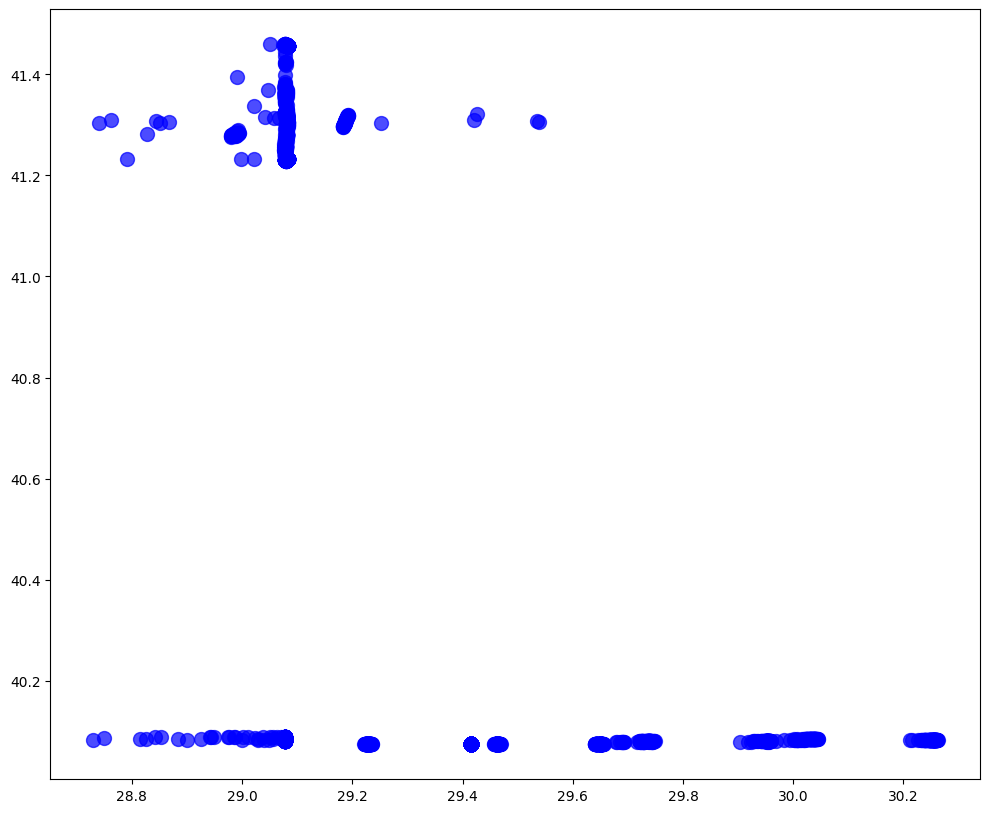

In [164]:
def predict_locations_from_measurements(model, p):
    model.eval()
    with torch.no_grad():
        
        pred_x = model.v_x(p).squeeze()
        pred_y = model.v_y(p).squeeze()
    return pred_x, pred_y

pred_x_m, pred_y_m = predict_locations_from_measurements(model, p)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    pred_x_m,
    pred_y_m,
    c="blue",
    s=100,
    alpha=0.7
)
###

###
plt.show()

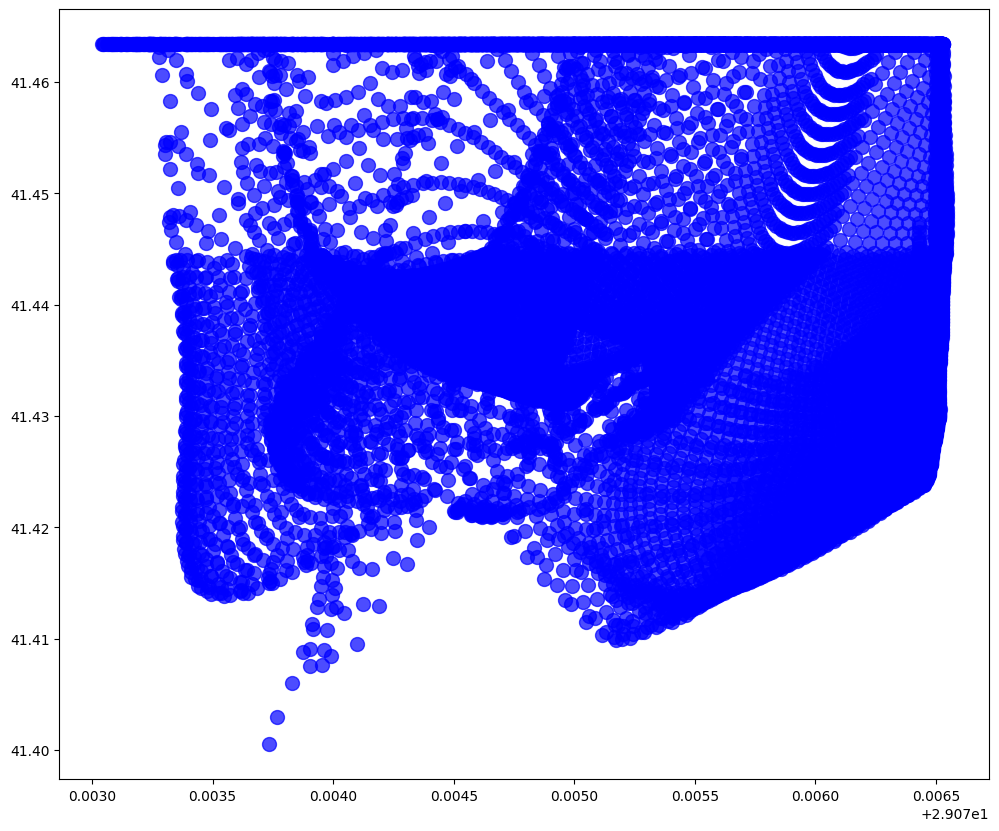

In [165]:
pred_x_m, pred_y_m = predict_locations_from_measurements(model, q)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    pred_x_m,
    pred_y_m,
    c="blue",
    s=100,
    alpha=0.7
)
###

###
plt.show()